In [2]:
import torch
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [37]:
words = open("names.txt", "r").read().splitlines()
chars = sorted(list(set("".join(words))))

s_i = {s:i+1 for i, s in enumerate(chars)}
s_i["."] = 0

i_s = {i:s for s, i in s_i.items()}

# building dataset

block_size = 3

def build_dataset(words):
    
    X, Y = [], []
    for w in words:
        # print(w)
        context = [0] * block_size
        
        for ch in w + ".":
            ix = s_i[ch]
            X.append(context)
            Y.append(ix)
            # print("".join(i_s[i] for i in context), "---->", i_s[ix])
            context = context[1:] + [ix]
            
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

In [38]:
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [ ]:
n_embd = 10 # dimensionality of character embedding vector
n_chars = 27
n_hidden = 200 # number of neurons in hidden layer

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((n_chars, n_embd), generator=g)

w1 = torch.randn((n_embd * block_size, n_hidden)) * (5/3) / (30 ** 0.5) # kaiming initialization
# b1 = torch.randn(n_hidden) * 0.01

w2 = torch.randn((n_hidden, n_chars)) * 0.01
b2 = torch.randn(n_chars) * 0.1

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, w1, w2, b2, bngain, bnbias]

for p in parameters:
    p.requires_grad = True

In [40]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre

lri = []

In [65]:
# training loop

max_steps = 200000
batch_size = 32

lossi = []
stepi = []

for i in range(max_steps):
    # make mini batch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    
    # linear layer
    # --------------------------------------
    emb = C[Xb]
    embcat = emb.view(-1, 30)
    hpreact = embcat @ w1 # + b1
    # --------------------------------------
    
    # batch normalization layer
    # --------------------------------------
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    
    hpreact = bngain * (hpreact - bnmeani) / (bnstdi + 0.001) + bnbias # added an epsilon to bnstdi
    
    with torch.no_grad():
        bnmean_running = 0.99 * bnmean_running + 0.001 * bnmeani
    
    with torch.no_grad():
            bnstd_running = 0.99 * bnstd_running + 0.001 * bnstdi
    # --------------------------------------
    
    # non-linear layer
    # --------------------------------------
    h = torch.tanh(hpreact)

    logits = h @ w2 + b2
    loss = F.cross_entropy(logits, Yb)
    # --------------------------------------
    
    # backward pass
    for p in parameters:
        p.grad = None
        
    loss.backward()
    
    # update
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
      
    # track stats  
    # lri.append(lre[i])
    if i % 1000 == 0:
        print(f"{i:7d}/{max_steps:7d}: {loss.item():4f}")
    
    stepi.append(i)
    lossi.append(loss.log10().item())

      0/ 200000: 3.289266
   1000/ 200000: 2.873432
   2000/ 200000: 2.389662
   3000/ 200000: 2.401881
   4000/ 200000: 2.279455
   5000/ 200000: 2.619958
   6000/ 200000: 2.554598
   7000/ 200000: 2.529699
   8000/ 200000: 2.222368
   9000/ 200000: 2.608847
  10000/ 200000: 2.245297
  11000/ 200000: 2.394393
  12000/ 200000: 2.144836
  13000/ 200000: 2.345366
  14000/ 200000: 2.388422
  15000/ 200000: 2.277293
  16000/ 200000: 2.547307
  17000/ 200000: 2.338591
  18000/ 200000: 2.272454
  19000/ 200000: 2.524541
  20000/ 200000: 2.275336
  21000/ 200000: 2.204555
  22000/ 200000: 2.389669
  23000/ 200000: 2.334114
  24000/ 200000: 2.197834
  25000/ 200000: 2.294312
  26000/ 200000: 2.329402
  27000/ 200000: 2.451576
  28000/ 200000: 2.450405
  29000/ 200000: 2.375177
  30000/ 200000: 2.553173
  31000/ 200000: 2.531005
  32000/ 200000: 2.098333
  33000/ 200000: 2.184049
  34000/ 200000: 2.339318
  35000/ 200000: 2.880133
  36000/ 200000: 2.210644
  37000/ 200000: 2.485442
  38000/ 200

In [1]:
# calibrate batch normalization at end of training

with torch.no_grad():
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    
    hpreact = embcat @ w1 # + b1
    
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

NameError: name 'torch' is not defined

In [60]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "dev": (Xdev, Ydev),
    }[split]
    
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    
    hpreact = embcat @ w1 # + b1
    #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)
    
    logits = h @ w2 + b2
    loss = F.cross_entropy(logits, y)
    
    print(split, loss.item())
    
split_loss("train")
split_loss("dev")

train 2.6188998222351074
dev 2.6178343296051025


In [155]:
g2 = torch.Generator().manual_seed(2147483647 + 10)
names = []

for _ in range(20):
    out = []
    context = [0] * block_size
    
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(-1, 30) @ w1) # + b1)
        logits = h @ w2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g2).item()
        context = context[1:] + [ix]
        if ix == 0:
            break
        out.append(ix)
        
    
    print("".join(i_s[i] for i in out))
        

chrpzhfadurleviflimrixgeathmhktassaljazhnelfeglyyan
kaqhil
ramargwcerihvdus
migbbhshriscelqhilthsrlingtttavbquwrythmgdearyxigfi
evphrrdy
emmidi
abgtnffrynfrynarasmindricsyannmellaozeljlojlmin
jurahndeph
adhn
mazondso
jian
ryndra
jalmanrxxxkdemiloqbridy
bra
aden
zitzgbrimildhkkycelllqwikmcklyah
nighnakhkbleskanttzameseff
kyam
chadordar
junylonokduhca


In [ ]:
g2 = torch.Generator().manual_seed(2147483647 + 10)
names = []

with open("backfeed.txt", "w") as file:
    for _ in range(32033):
        out = []
        context = [0] * block_size
        
        while True:
            emb = C[torch.tensor([context])]
            h = torch.tanh(emb.view(-1, 30) @ w1) # + b1)
            logits = h @ w2 + b2
            probs = F.softmax(logits, dim=1)
            ix = torch.multinomial(probs, num_samples=1, generator=g2).item()
            context = context[1:] + [ix]
            if ix == 0:
                break
            out.append(ix)
            
        
        names.append("".join(i_s[i] for i in out))
        file.write(f"{"".join(i_s[i] for i in out)}\n")
        

In [ ]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.randn(fan_out) * 0.1 if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight
        
        if self.bias is not None:
            self.out += self.bias
            
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.001):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        
        # parameters
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        
        # buffers (trained by momentum update)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
        
    def __call__(self, x):
        # forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        
        # update buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momuntum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        
        return self.out
        
    def parameters(self):
        return []

n_embd = 10 # dimensionality of character embedding vectors
n_hidden = 100 # neurons in hidden layer

g = torch.Generator().manual_seed(2147483647)

vocab_size = 27

C = torch.randn((vocab_size, n_embd), generator=g)

layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden,            n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden,            n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden,            n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden,            n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear          (n_hidden,  vocab_size),
]


with torch.no_grad():
    # make last layer less confident
    layers[-1].gamma *= 0.1
    
    # apply gain on all other layers
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3
            
parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters

for p in parameters:
    p.requires_grad = True
    

46497


In [170]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # make mini batches
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # fwd pass
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    
    loss = F.cross_entropy(x, Yb)
    
    # backprop
    for layer in layers:
        layer.out.retain_grad()
    
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.001
    for p in parameters:
        p.data += -lr * p.grad
        
    # track stats  
    if i % 10000 == 0:
        print(f"{i:7d}/{max_steps:7d}: {loss.item():4f}")
        
    break

    lossi.append(loss.log10().item())

      0/ 200000: 1.749829


layer 1 (      Tanh): mean -0.000020, std 4.865911e-03
layer 3 (      Tanh): mean -0.000028, std 3.826470e-03
layer 5 (      Tanh): mean -0.000084, std 3.891258e-03
layer 7 (      Tanh): mean -0.000123, std 4.204307e-03
layer 9 (      Tanh): mean -0.000045, std 4.621719e-03


Text(0.5, 1.0, 'gradient distribution')

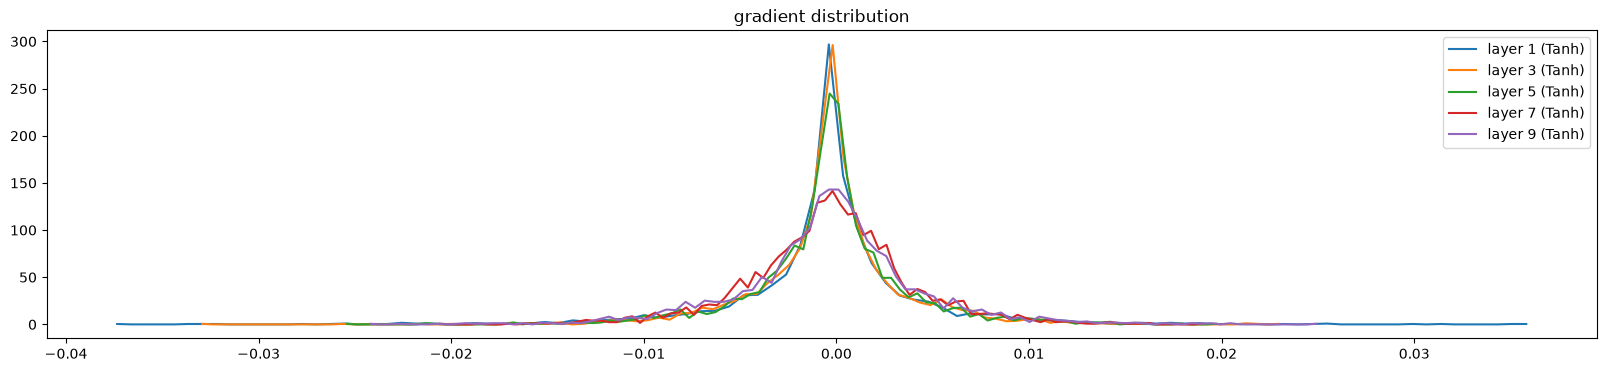

In [171]:
plt.figure(figsize=(20, 4))
legends = []

for i, layer in enumerate(layers[:-1]): # exclude output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print("layer %d (%10s): mean %+f, std %e" % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"layer {i} ({layer.__class__.__name__})")

plt.legend(legends)
plt.title("gradient distribution")
        

In [172]:
g2 = torch.Generator().manual_seed(2147483647 + 10)
names = []

for _ in range(20):
    out = []
    context = [0] * block_size
    
    while True:
        print(context)
        emb = C[torch.tensor([context])]
        out_ = emb.view(-1, 1)
        for layer in layers:
            out_ = layer(out_)
        
        
        """ for layer in layers:
            out_ = layer(torch.tensor(out)) # + b1) """
        probs = F.softmax(out_, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        if ix == 0:
            break
        out.append(ix)
        
    
    print("".join(i_s[i] for i in out))
        

[0, 0, 0]


RuntimeError: mat1 and mat2 shapes cannot be multiplied (30x1 and 30x100)

In [174]:
g2 = torch.Generator().manual_seed(2147483647 + 11)

for _ in range(20):
    out = []
    context = [0] * block_size

    while True:
        emb = C[torch.tensor([context])]
        x = emb.view(1, -1)

        for layer in layers:
            x = layer(x)

        probs = F.softmax(x, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g2).item()

        context = context[1:] + [ix]
        if ix == 0:
            break
        out.append(ix)

    print("".join(i_s[i] for i in out))

nah
trine
hambria
tyrie
payton
mavivia
tamarienana
milo
eli
haylaj
aaliha
jahabashanouranthhton
yah
niver
ana
kata
zanna
raziya
ameer
keian
